# $B-L$ portal — bounds figure

Reproduces the `BLPortal` bounds plot in the $(m_X,\, \varepsilon \cdot g_{B-L})$ plane. Pure post-processing: loads the four precomputed scans `output/blP/relic_joint_aX*_r*.dat` (produced by `scripts/get_bLPDM_bounds_all.py`), then evaluates direct-detection limits on a finer mass grid.

Two side-by-side panels, $m_X/m_{Z^\prime} = 2.5$ and $5.0$, each overlaying $\alpha_X = 10^{-3}$ (solid) and $10^{-2}$ (dashed). Curves shown: relic-abundance line (joint + secluded), BBN hadronic-injection upper bound, direct-detection envelope (LZ + XENONnT), Xe neutrino fog, and the thermalisation-floor heuristic. Lower twin axes plot $\langle\sigma v\rangle_X$ on the relic line against the WIMP value $4\times 10^{-26}\,{\rm cm^3/s}$.

The y-axis is $\varepsilon \cdot g_{B-L}$ — the `BLPortal` model defaults to $g_{B-L} = 1$, so the plotted quantity is the *effective* portal coupling product (see README §Models). Coupling to neutrinos (relative to baryon portal) opens up additional decay channels relevant for the BBN bound.

Output: `letter_figs/blP_fig_v0.pdf`.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
import matplotlib.colors as mcolors
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from hidden_sector_DM.HiddenSectorDM import Cosmology, BLPortal, BoltzmannSolver

plt.style.use('mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

In [2]:
def load_relic(fname):
    # Column names (7 entries)
    keys = [
        "mXs", "mYs", "epsXs", "epsXs_bbn",
        "Och2", "GoH_handoff", "regime"
    ]
    # Load data (skip commented lines)
    data = np.loadtxt(fname, comments="#")
    # Convert to dictionary
    return {k: data[:, i] for i, k in enumerate(keys)}

In [3]:
HBARC_GEV_CM = 1.9732698044e-14        # GeV·cm
C_CM_S       = 2.99792458e10           # cm/s (exact)
GEVm2_TO_CM3_S = HBARC_GEV_CM**2 * C_CM_S 

def sigmav_XX_to_YY_swave(mX: float, mY: float, alphaX: float) -> float:
    """<sigma v> for X Xbar -> Y Y  (s-wave, finite mY)."""
    rv = mY / mX
    return (4.0 * np.pi * alphaX**2 / mX**2
            * (1.0 - rv**2)**1.5 / (2.0 - rv**2)**2)*GEVm2_TO_CM3_S
aXs_rs_str=['aX1e-03_r2.5','aX1e-03_r5.0','aX1e-02_r2.5','aX1e-02_r5.0']
aXs_rs_vals=np.array([[1e-3,2.5],[1e-3,5],[1e-2,2.5],[1e-2,5]])
aXs_rs_tex=np.array([[r'$10^{-3}$','2.5'],[r'$10^{-3}$','5'],
                     [r'$10^{-2}$','2.5'],[r'$10^{-2}$','5']])
dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
therm_floors=[]
for i in trange(len(aXs_rs_str)):
    dat1 = load_relic("../output/blP/relic_joint_"+str(aXs_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1, regime_bools = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn'], dat1['regime']
    svs1=np.array([sigmav_XX_to_YY_swave(mXs1[k],mXs1[k]/aXs_rs_vals[i][1],aXs_rs_vals[i][0]) for k in range(len(mXs1))])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    mask = ~np.isnan(epsXs_bbn1)
    idx_th=np.argmax(mask)-1
    mX_therm,eps_therm= mXs1[idx_th],epsXs1[idx_th]
    therm_floors.append([mX_therm, eps_therm])
    i0 = np.argmin(mXs1[mask])
    mXs_bbn_interp, epsXs_bbn_interp = mXs1[mask][i0:], epsXs_bbn1[mask][i0:]
    bbn_bound=interp1d(np.log10(mXs_bbn_interp), np.log10(epsXs_bbn_interp), kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=10**bbn_bound(np.log10(mXs_bbn_dd))
    epsXs_LZ=np.ones(len(mXs_bbn_dd))
    epsXs_Xe=np.ones(len(mXs_bbn_dd))
    epsXs_nu=np.ones(len(mXs_bbn_dd))
    for j in range(len(mXs_bbn_dd)):
        model = BLPortal(
          mX=mXs_bbn_dd[j],
          mY=mXs_bbn_dd[j]/aXs_rs_vals[i][1],
          alphaX=aXs_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_Xe[j]= solver.find_epsilon_DD(constraint='XENONnT',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))    
        except:
            continue
    epsXs_LZ[np.isnan(epsXs_LZ)] = 1
    epsXs_Xe[np.isnan(epsXs_Xe)] = 1
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,
          'epsXs_LZ':epsXs_LZ,'epsXs_XenT':epsXs_Xe,'epsXs_nu':epsXs_nu, 'svXs':svs1}
    dats.append(Dict)
    del Dict
therm_floors=np.array(therm_floors)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  4.11it/s]


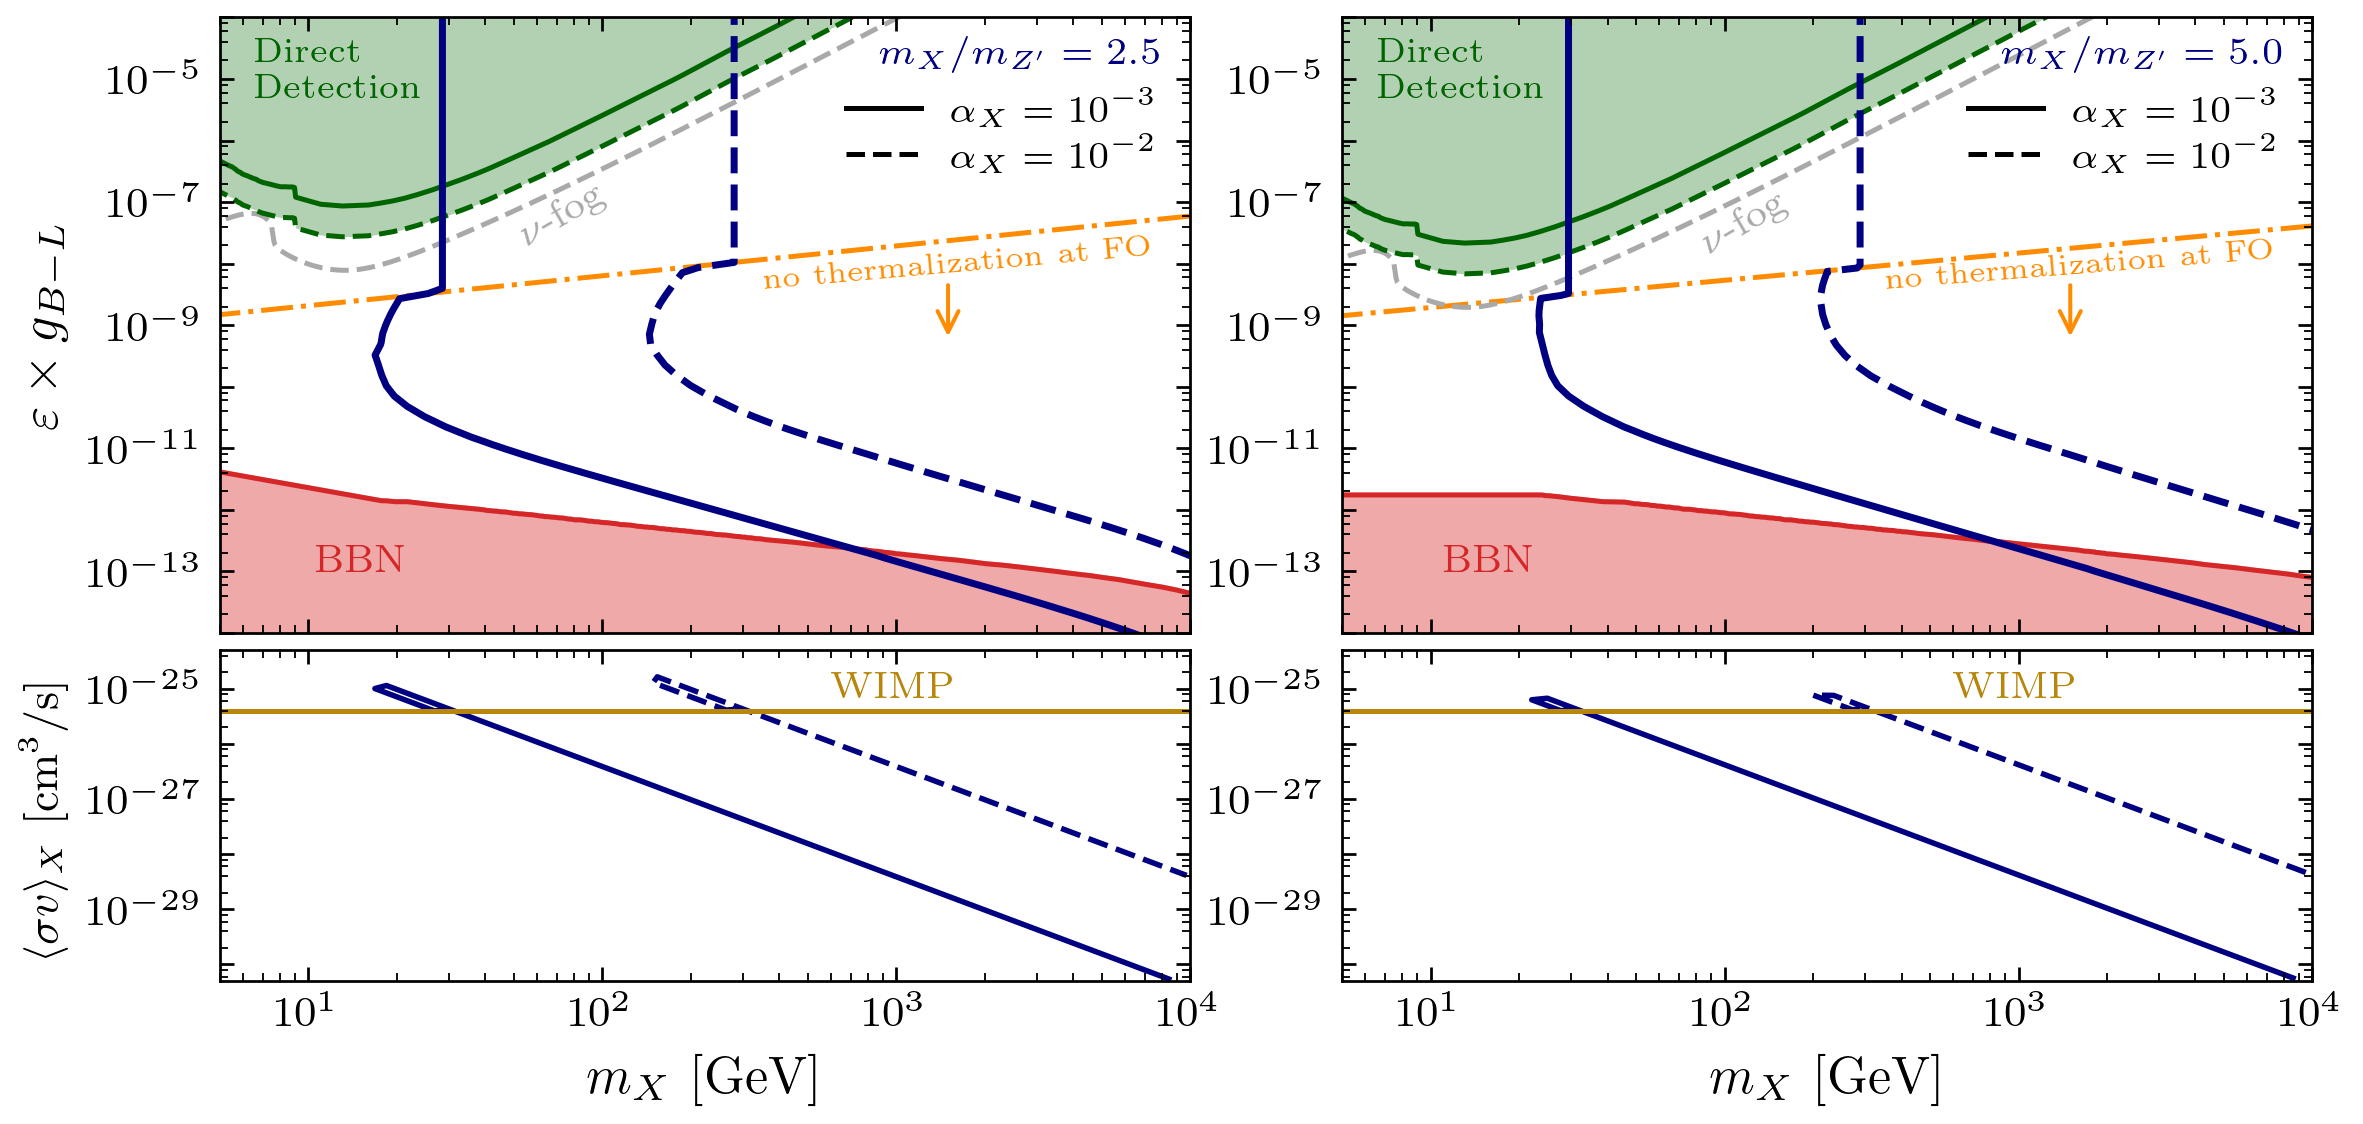

In [13]:
import matplotlib.pyplot as plt
import matplotlib.legend_handler as lh
from matplotlib.lines import Line2D
def color_shades(color, n, lightest_alpha=0.25):
    """Generate n shades from `color` to lighter, blended toward white.

    Parameters
    ----------
    color : str or RGB tuple
        Base color (e.g. "tab:blue").
    n : int
        Number of shades.
    lightest_alpha : float
        Fraction of base color in the lightest shade (0=white, 1=original).

    Returns
    -------
    list of hex color strings, from darkest to lightest.
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    fracs = np.linspace(1.0, lightest_alpha, n)
    return [mcolors.to_hex(rgb * f + white * (1 - f)) for f in fracs]


class MultiLineHandler(lh.HandlerBase):
    def __init__(self, colors, linestyle='-', linewidth=1):
        self.colors = colors
        self.linestyle = linestyle
        self.linewidth = linewidth
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        lines = []
        n = len(self.colors)
        for i, color in enumerate(self.colors):
            y = height - (i + 0.5) * height / n
            line = Line2D([xdescent, xdescent + width], [y, y],
                          color=color, linestyle=self.linestyle,
                          linewidth=self.linewidth, transform=trans)
            lines.append(line)
        return lines
def with_offset(x, y, offset=0.03, log=True):
    u, v = (np.log10(x), np.log10(y)) if log else (np.asarray(x, float), np.asarray(y, float))
    tu, tv = np.gradient(u), np.gradient(v)
    n = np.hypot(tu, tv); n[n == 0] = 1
    u = u - offset * tv / n
    v = v + offset * tu / n
    return (10**u, 10**v) if log else (u, v)

colors = ['tab:grey', 'navy', 'tab:red']
reds=color_shades('tab:red', 2,lightest_alpha=0.4)
#greys=color_shades('tab:grey', 2,lightest_alpha=0.4)
greys=color_shades('darkgreen', 2,lightest_alpha=0.3)
silvers=color_shades('darkgrey', 2,lightest_alpha=0.1)
# Dummy handles (just used as dict keys)
solid_handle = Line2D([], [])
dashed_handle = Line2D([], [])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.75))
gs1 = GridSpec(31,30,figure=fig1,hspace=1.2)
ax1 = fig1.add_subplot(gs1[:20,:14])
ax2 = fig1.add_subplot(gs1[:20,16:])
ax12 = fig1.add_subplot(gs1[20:,:14])
ax22 = fig1.add_subplot(gs1[20:,16:])
lss=['-','--', ':']
ZOs=[[-0.1,-.9],[-.1,-0.9],[-.1,-0.9]]
axs=[ax1,ax2]
axs1=[ax12, ax22]
therm_floor_r25=10**(interp1d(np.log10(therm_floors[::2][:,0]),np.log10(therm_floors[::2][:,1]), kind="linear", fill_value="extrapolate", bounds_error=False)(np.log10(dats[0]['mXs_bbn_dd'])))
therm_floor_r50=10**(interp1d(np.log10(therm_floors[1::2][:,0]),np.log10(therm_floors[1::2][:,1]), kind="linear", fill_value="extrapolate", bounds_error=False)(np.log10(dats[1]['mXs_bbn_dd'])))
ax1.plot(dats[0]['mXs_bbn_dd'],therm_floor_r25, lw=1, ls='-.', c='darkorange',zorder=-1)
ax2.plot(dats[1]['mXs_bbn_dd'],therm_floor_r50, lw=1, ls='-.', c='darkorange',zorder=-1)
for j in range(2):
    ax1.plot(dats[2*j]['mXs'],dats[2*j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    x1,y1=with_offset(dats[2*j]['mXs'][::5],dats[2*j]['svXs'][::5])
    ax12.plot(x1,y1,lw=1.1,c='navy',ls=lss[j],zorder=ZOs[j][0])
    #ax1.plot(np.NaN,np.NaN,lw=1.1,c='navy',ls=lss[j],label=r'$\alpha_X=\,$'+str(aXs_rs_tex[2*j][0]))
    #ax2.plot(np.NaN,np.NaN,lw=1.1,c='navy',ls=lss[j],label=r'$\alpha_X=\,$'+str(aXs_rs_tex[2*j][0]))
    if j==0:
        ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_bbn'],lw=1,color=reds[1],alpha=1,zorder=ZOs[j][1])
        ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
        ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_bbn'],lw=1,color=reds[1],alpha=1,zorder=ZOs[j][1])
        ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    if j==1:
        ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=1,color=silvers[0],ls=lss[j],zorder=ZOs[j][1])
        #ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_nu'],lw=1,color=silvers[1],alpha=1,zorder=-2)
        ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=1,color=silvers[0],ls=lss[j],zorder=ZOs[j][1])
        #ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_nu'],lw=1,color=silvers[1],alpha=1,zorder=-2)
    epsXs_DD = np.minimum(dats[2*j]['epsXs_LZ'], dats[2*j]['epsXs_XenT'])
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_LZ'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.plot(dats[2*j]['mXs_bbn_dd'],epsXs_DD,lw=1,color=greys[0],ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    epsXs_DD = np.minimum(dats[2*j+1]['epsXs_LZ'], dats[2*j+1]['epsXs_XenT'])
    ax2.plot(dats[2*j+1]['mXs'],dats[2*j+1]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    x2,y2=with_offset(dats[2*j+1]['mXs'][::5],dats[2*j+1]['svXs'][::5])
    ax22.plot(x2,y2,lw=1.1,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_LZ'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_XenT'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],epsXs_DD,lw=1,color=greys[0],ls=lss[j],zorder=ZOs[j][1])
    #ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel(r"$\varepsilon\times g_{B-L}$")
#ax12.set_ylabel(r"$\langle \sigma v\rangle_{\rm s\mbox{-}wave}\,\,[{\rm cm^3}/{\rm s}]$", fontsize=9)
ax12.set_ylabel(r"$\langle \sigma v\rangle_{X}\,\,[{\rm cm^3}/{\rm s}]$", fontsize=9)
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-14,1e-4)
    ax.set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['',r'$10^{-13}$','',r'$10^{-11}$','',r'$10^{-9}$','',r'$10^{-7}$','',r'$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xticklabels([])
    ax.legend(
    [solid_handle, dashed_handle],
    [r'$\alpha_X=10^{-3}$', r'$\alpha_X=10^{-2}$'],
    handler_map={
        solid_handle:  MultiLineHandler('k', linestyle='-'),
        dashed_handle: MultiLineHandler('k', linestyle='--'),
    },
    loc=(.63, 0.72),
             )
for ax in axs1:
    ax.set_yscale("log")
    ax.set_ylim(5e-31,5e-25)
    ax.set_yticks([1e-30,1e-29,1e-28,1e-27,1e-26, 1e-25])
    ax.set_yticklabels(['',r'$10^{-29}$','',r'$10^{-27}$','',r'$10^{-25}$'])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xlabel(r"$m_X$ [GeV]")
ax1.text(3.5e2,4e-9,'no thermalization at FO',fontsize=6,color='darkorange', rotation=5)
ax2.text(3.5e2,4e-9,'no thermalization at FO',fontsize=6,color='darkorange', rotation=4.5)
# Draw arrow (shaft + head)
start = (1.5e3, 6.5e-9)
end = (1.5e3, 4.5e-10)
start2 = (1.5e3, 6.5e-9)
end2 = (1.5e3, 4.5e-10)
ax1.annotate('', xy=end, xytext=start,
            arrowprops=dict(arrowstyle='->', lw=.8, color='darkorange'))
ax2.annotate('', xy=end2, xytext=start2,
            arrowprops=dict(arrowstyle='->', lw=.8, color='darkorange'))
ax12.axhline(4e-26,lw=1,color='darkgoldenrod',ls="-",zorder=0.5)
ax22.axhline(4e-26,lw=1,color='darkgoldenrod',ls="-",zorder=0.5)
ax1.text(6.6,5e-6,"Direct\nDetection",fontsize=7,color=greys[0])
ax2.text(6.6,5e-6,"Direct\nDetection",fontsize=7,color=greys[0])
ax1.text(10.5,1e-13,"BBN",fontsize=8,color='tab:red')
ax2.text(11,1e-13,"BBN",fontsize=8,color='tab:red')
ax1.text(50,2e-8,r"$\nu$-fog",fontsize=8,color=silvers[0],rotation=30)
ax2.text(80,1.5e-8,r"$\nu$-fog",fontsize=8,color=silvers[0],rotation=30)
ax1.text(8e3,1.8e-5,r'$m_X/m_{Z^\prime}=2.5$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax2.text(8e3,1.8e-5,r'$m_X/m_{Z^\prime}=5.0$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
#ax12.text(6e2,8e-26,r' $\langle \sigma v \rangle_{\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
#ax22.text(6e2,8e-26,r' $\langle \sigma v \rangle_{\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax12.text(6e2,7e-26,r' ${\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax22.text(6e2,7e-26,r' ${\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')

plt.savefig("../letter_figs/blP_fig_v0.png")
plt.savefig("../letter_figs/blP_fig_v0.pdf")
plt.show()
plt.close()